## Hierarchical Agent Architecture

### Reward Formula

```python
reward = alpha_returns * log_return - alpha_mdd * current_drawdown - alpha_vol * volatility + exploration_bias
```

This composite reward:
- Maximizes log returns (more stable than arithmetic returns)
- Penalizes current drawdown (prevents catastrophic losses)
- Penalizes volatility (encourages smooth returns)
- Adds small exploration bonus (prevents premature convergence)

### Reward Parameters by Level

#### Base Agents (Sentiment and Technical)
**Parameters:** `alpha_returns=1.0, alpha_mdd=0.3, alpha_vol=0.3, exploration_bias=0.01`

**Design Rationale:**
- Lower risk penalties (0.3 vs 0.5) encourage exploration of the strategy space
- Base agents learn diverse approaches to their specific information
- Small exploration bias maintains some randomness
- Each agent becomes a specialist in its domain

#### Super Agent
**Parameters:** `alpha_returns=1.0, alpha_mdd=0.5, alpha_vol=0.5, exploration_bias=0.01`

**Design Rationale:**
- Higher risk penalties (0.5) for more conservative blending
- Learns to combine base agent recommendations
- Higher exploration bias (0.01) to try different blending strategies
- Balances exploitation of base agents with risk management

#### Meta Agent
**Parameters:** `alpha_returns=1.0, alpha_mdd=0.5, alpha_vol=0.5, exploration_bias=0.01`

**Design Rationale:**
- Same risk penalties as super agent (coherent hierarchy)
- Lower exploration bias (0.001) for stable final decisions
- Top-level risk manager with full information
- Makes conservative portfolio allocations

### Reward Scale Analysis

**Typical Reward Ranges (monthly data):**
- Log returns: [-0.15, +0.15] → contributes [-0.15, +0.15]
- Drawdown: [0, 0.5] → penalty [-0.25, 0] (with alpha=0.5)
- Volatility: [0, 0.3] → penalty [-0.15, 0] (with alpha=0.5)
- Exploration: +0.001 to +0.01
- **Total reward range: approximately [-0.5, +0.2]**

All agents operate on the same scale, ensuring:
- Consistent learning dynamics
- Comparable value functions
- Stable training across hierarchy

### Key Design Benefits

1. **Coherent Objectives:** All agents optimize the same core goal
2. **Hierarchical Specialization:** Different penalty weights create natural roles
3. **Stable Training:** Consistent reward scales prevent instability
4. **Interpretability:** Clear relationship between levels
5. **Agent Synchronization:** Sub-agents update dynamically with aligned objectives

### Agent Update Strategy

Base agents are updated AFTER each environment transition:
- Sentiment agent: updated with current sentiment features
- Technical agent: updated with current technical features  
- Super agent: updated with current base agent weights + regime
- All updates maintain proper temporal alignment (no lookahead bias)

This creates a dynamic hierarchy where agents adapt to current market conditions while maintaining coherent optimization objectives.

### Validation Metrics

Monitor to verify hierarchy effectiveness:
1. **Reward convergence:** All agents should show stable learning curves
2. **Agent weight diversity:** Base agents should have distinct strategies
3. **Hierarchical improvement:** Performance should improve: Base < Super < Meta
4. **Risk-adjusted returns:** Sharpe ratios should consistently improve up the hierarchy
5. **Drawdown control:** Max drawdown should decrease at higher levels


In [1]:
import os
from typing import Tuple, Dict, Any

import numpy as np
import pandas as pd

from stable_baselines3 import PPO, SAC

from sentiment_enviroment import SentimentEnv
from technical_enviroment import TechnicalEnv
from super_agent_envoriment import SuperAgentEnv
from meta_agent_enviroment import MetaAgentEnv
from custom_function import split_data_chronologically, add_regime_indicator
from agent_wrapper import AgentWrapper, EarlyStoppingCallback, evaluate_agent
import warnings

warnings.filterwarnings('ignore')


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def load_pretrained_agents(
    sentiment_model_path,
    technical_model_path,
    sentiment_train_env,
    technical_train_env,
    seed=None):

    if not os.path.exists(sentiment_model_path):
        raise FileNotFoundError(f"Sentiment model not found at {sentiment_model_path}")
    if not os.path.exists(technical_model_path):
        raise FileNotFoundError(f"Technical model not found at {technical_model_path}")

    # Determine algorithm type based on file naming convention
    if 'ppo' in sentiment_model_path.lower():
        sentiment_model = PPO.load(sentiment_model_path, env=sentiment_train_env)
        sentiment_algo = 'PPO'
    else:
        sentiment_model = SAC.load(sentiment_model_path, env=sentiment_train_env)
        sentiment_algo = 'SAC'

    if 'ppo' in technical_model_path.lower():
        technical_model = PPO.load(technical_model_path, env=technical_train_env)
        technical_algo = 'PPO'
    else:
        technical_model = SAC.load(technical_model_path, env=technical_train_env)
        technical_algo = 'SAC'

    sentiment_agent = AgentWrapper(sentiment_model, sentiment_train_env, sentiment_algo, 'sentiment')
    technical_agent = AgentWrapper(technical_model, technical_train_env, technical_algo, 'technical')

    # Reset to initialize internal weight vectors with seed control
    sentiment_agent.reset(seed=seed)
    technical_agent.reset(seed=seed)
    
    # Validate observation spaces
    print(f"Sentiment agent observation space: {sentiment_train_env.observation_space.shape}")
    print(f"Technical agent observation space: {technical_train_env.observation_space.shape}")
    print(f"Agents loaded and validated successfully.")

    return sentiment_agent, technical_agent

In [3]:
def train_super_agent(
    super_train_env,
    super_val_env,
    timesteps=50_000,
    algorithm='ppo',
    ppo_params=None,
    sac_params=None,
    early_stopping=True,
    early_stopping_params=None,
    save_path='./models/super'
):
    """Train a super agent with early stopping."""
    os.makedirs(save_path, exist_ok=True)
    algorithm = algorithm.lower()
    
    # Instantiate model
    if algorithm == 'ppo':
        params = ppo_params or {}
        model = PPO('MlpPolicy', super_train_env, **params)
    else:
        params = sac_params or {}
        model = SAC('MlpPolicy', super_train_env, **params)
    
    # Configure early stopping callback
    if early_stopping:
        es_params = early_stopping_params or {}
        callback = EarlyStoppingCallback(
            val_env=super_val_env,
            eval_freq=es_params.get('eval_freq', 2_000),
            patience=es_params.get('patience', 5),
            min_delta=es_params.get('min_delta', 0.01),
            save_path=os.path.join(save_path, 'checkpoint'),
            verbose=1,
        )
    else:
        callback = None
    
    # Train the model
    model.learn(total_timesteps=timesteps, callback=callback)
    
    # Load the best model if early stopping saved one
    if early_stopping and callback and callback.best_model_path:
        if algorithm == 'ppo':
            model = PPO.load(callback.best_model_path, env=super_train_env)
        else:
            model = SAC.load(callback.best_model_path, env=super_train_env)
    
    return model, callback


def train_meta_agent(
    meta_train_env,
    meta_val_env,
    timesteps=50_000,
    algorithm='ppo',
    ppo_params=None,
    sac_params=None,
    early_stopping=True,
    early_stopping_params=None,
    save_path='./models/meta'
):
    """Train a meta agent with early stopping."""
    os.makedirs(save_path, exist_ok=True)
    algorithm = algorithm.lower()
    
    # Instantiate model
    if algorithm == 'ppo':
        params = ppo_params or {}
        model = PPO('MlpPolicy', meta_train_env, **params)
    else:
        params = sac_params or {}
        model = SAC('MlpPolicy', meta_train_env, **params)
    
    # Configure early stopping callback
    if early_stopping:
        es_params = early_stopping_params or {}
        callback = EarlyStoppingCallback(
            val_env=meta_val_env,
            eval_freq=es_params.get('eval_freq', 2_000),
            patience=es_params.get('patience', 5),
            min_delta=es_params.get('min_delta', 0.01),
            save_path=os.path.join(save_path, 'checkpoint'),
            verbose=1,
        )
    else:
        callback = None
    
    # Train the model
    model.learn(total_timesteps=timesteps, callback=callback)
    
    # Load the best model if early stopping saved one
    if early_stopping and callback and callback.best_model_path:
        if algorithm == 'ppo':
            model = PPO.load(callback.best_model_path, env=meta_train_env)
        else:
            model = SAC.load(callback.best_model_path, env=meta_train_env)
    
    return model, callback

In [ ]:
# Cell: Environment Builder Functions
def build_super_agent_envs(
    train_prices,
    val_prices,
    test_prices,
    sentiment_train_env,
    sentiment_val_env,
    sentiment_test_env,
    technical_train_env,
    technical_val_env,
    technical_test_env,
    sentiment_agent,
    technical_agent,
    regime_indicators=None,
    initial_capital=100_000,
    transaction_cost=0.001,
    alpha_returns=1.0,
    alpha_mdd=0.5,
    alpha_vol=0.5,
    exploration_bias=0.01
):
    # Prepare regime indicators for each split if provided
    regime_train = regime_indicators.get('train') if regime_indicators else None
    regime_val = regime_indicators.get('val') if regime_indicators else None
    regime_test = regime_indicators.get('test') if regime_indicators else None

    # Create environments with configurable reward parameters
    super_train_env = SuperAgentEnv(
        price_data=train_prices,
        sentiment_agent=sentiment_agent,
        technical_agent=technical_agent,
        regime_indicators=regime_train,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        alpha_returns=alpha_returns,
        alpha_mdd=alpha_mdd,
        alpha_vol=alpha_vol,
        exploration_bias=exploration_bias,
    )
    super_val_env = SuperAgentEnv(
        price_data=val_prices,
        sentiment_agent=sentiment_agent,
        technical_agent=technical_agent,
        regime_indicators=regime_val,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        alpha_returns=alpha_returns,
        alpha_mdd=alpha_mdd,
        alpha_vol=alpha_vol,
        exploration_bias=exploration_bias,
    )
    super_test_env = SuperAgentEnv(
        price_data=test_prices,
        sentiment_agent=sentiment_agent,
        technical_agent=technical_agent,
        regime_indicators=regime_test,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        alpha_returns=alpha_returns,
        alpha_mdd=alpha_mdd,
        alpha_vol=alpha_vol,
        exploration_bias=exploration_bias,
    )
    return super_train_env, super_val_env, super_test_env


def build_meta_agent_envs(
    train_prices,
    val_prices,
    test_prices,
    train_technical,
    val_technical,
    test_technical,
    train_sentiment,
    val_sentiment,
    test_sentiment,
    sentiment_agent,
    technical_agent,
    super_agent_model,
    super_train_env,
    super_val_env,
    super_test_env,
    regime_indicators=None,
    initial_capital=100_000,
    transaction_cost=0.001,
    alpha_returns=1.0,
    alpha_mdd=0.5,
    alpha_vol=0.5,
    exploration_bias=0.01
):
    # Wrap the super agent model
    if isinstance(super_agent_model, PPO):
        super_algo = 'PPO'
    else:
        super_algo = 'SAC'
    super_agent_wrapper_train = AgentWrapper(super_agent_model, super_train_env, super_algo, 'super')
    super_agent_wrapper_val = AgentWrapper(super_agent_model, super_val_env, super_algo, 'super')
    super_agent_wrapper_test = AgentWrapper(super_agent_model, super_test_env, super_algo, 'super')

    # Reset all wrappers
    super_agent_wrapper_train.reset()
    super_agent_wrapper_val.reset()
    super_agent_wrapper_test.reset()

    # Extract regime indicators
    regime_train = regime_indicators.get('train') if regime_indicators else None
    regime_val = regime_indicators.get('val') if regime_indicators else None
    regime_test = regime_indicators.get('test') if regime_indicators else None

    meta_train_env = MetaAgentEnv(
        price_data=train_prices,
        features=train_technical,
        sentiment_features=train_sentiment,
        sentiment_agent=sentiment_agent,
        technical_agent=technical_agent,
        super_agent=super_agent_wrapper_train,
        regime_indicators=regime_train,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        alpha_returns=alpha_returns,
        alpha_mdd=alpha_mdd,
        alpha_vol=alpha_vol,
        exploration_bias=exploration_bias,
    )
    meta_val_env = MetaAgentEnv(
        price_data=val_prices,
        features=val_technical,
        sentiment_features=val_sentiment,
        sentiment_agent=sentiment_agent,
        technical_agent=technical_agent,
        super_agent=super_agent_wrapper_val,
        regime_indicators=regime_val,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        alpha_returns=alpha_returns,
        alpha_mdd=alpha_mdd,
        alpha_vol=alpha_vol,
        exploration_bias=exploration_bias,
    )
    meta_test_env = MetaAgentEnv(
        price_data=test_prices,
        features=test_technical,
        sentiment_features=test_sentiment,
        sentiment_agent=sentiment_agent,
        technical_agent=technical_agent,
        super_agent=super_agent_wrapper_test,
        regime_indicators=regime_test,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        alpha_returns=alpha_returns,
        alpha_mdd=alpha_mdd,
        alpha_vol=alpha_vol,
        exploration_bias=exploration_bias,
    )
    return meta_train_env, meta_val_env, meta_test_env

In [5]:
# Load data
price_data = pd.read_csv('output_data/price_data.csv', index_col=0, parse_dates=True)
technical_features = pd.read_csv('output_data/technical_features.csv', index_col=0, parse_dates=True)
sentiment_features = pd.read_csv('output_data/sentiment_features.csv', index_col=0, parse_dates=True)
regime = pd.read_csv('output_data/regime_indicators.csv', index_col=0, parse_dates=True)

# Split data chronologically
splits = split_data_chronologically(price_data, technical_features, sentiment_features)
(train_prices, train_technical, train_sentiment) = splits['train']
(val_prices, val_technical, val_sentiment) = splits['val']
(test_prices, test_technical, test_sentiment) = splits['test']

# Build regime splits with date-based indexing
regime_splits = None
if regime is not None:
    regime_train = regime.loc[train_prices.index]
    regime_val = regime.loc[val_prices.index]
    regime_test = regime.loc[test_prices.index]
    
    # Validate alignment
    assert len(regime_train) == len(train_prices), "Regime train length mismatch!"
    assert len(regime_val) == len(val_prices), "Regime val length mismatch!"
    assert len(regime_test) == len(test_prices), "Regime test length mismatch!"
    
    print(f"Regime indicators aligned: Train={len(regime_train)}, Val={len(regime_val)}, Test={len(regime_test)}")
    
    regime_splits = {
        'train': regime_train,
        'val': regime_val,
        'test': regime_test,
    }


DATA SPLITTING

Total data: 129 months
Date range: 2015-02-28 00:00:00 to 2025-10-31 00:00:00

DATA SPLIT SUMMARY:
Train:  77 months (60%) | 2015-02 to 2021-06
Val:    25 months (20%) | 2021-07 to 2023-07
Test:   27 months (20%) | 2023-08 to 2025-10

No data leakage - splits are properly separated
Regime indicators aligned: Train=77, Val=25, Test=27


In [6]:
# Instantiate base environments
sentiment_train_env = SentimentEnv(train_prices, train_sentiment)
sentiment_val_env = SentimentEnv(val_prices, val_sentiment)
sentiment_test_env = SentimentEnv(test_prices, test_sentiment)

technical_train_env = TechnicalEnv(train_prices, train_technical)
technical_val_env = TechnicalEnv(val_prices, val_technical)
technical_test_env = TechnicalEnv(test_prices, test_technical)

# Load pre-trained base agents
sentiment_model_path = 'models/Sentiment_PPO_best.zip'
technical_model_path = 'models/Technical_PPO_best.zip'

sentiment_agent, technical_agent = load_pretrained_agents(
    sentiment_model_path,
    technical_model_path,
    sentiment_train_env,
    technical_train_env,
    seed=42
)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Sentiment agent observation space: (53,)
Technical agent observation space: (110,)
Agents loaded and validated successfully.


In [7]:
# Experiment Configuration
experiment_configs = {
    'baseline': {
        'alpha_returns': 5.0,
        'alpha_mdd': 0.5,
        'alpha_vol': 0.5,
        'exploration_bias': 0.01,
        'transaction_cost_super': 0.001,
        'transaction_cost_meta': 0.001,
    },
    'aggressive': {
        'alpha_returns': 1.0,
        'alpha_mdd': 0.3,
        'alpha_vol': 0.3,
        'exploration_bias': 0.02,
        'transaction_cost_super': 0.001,
        'transaction_cost_meta': 0.001,
    },
    'conservative': {
        'alpha_returns': 1.0,
        'alpha_mdd': 0.7,
        'alpha_vol': 0.7,
        'exploration_bias': 0.005,
        'transaction_cost_super': 0.001,
        'transaction_cost_meta': 0.001,
    },
}

# Select experiment
experiment_name = 'baseline'
config = experiment_configs[experiment_name]
print(f"Running experiment: {experiment_name}")
print(f"Config: {config}")

Running experiment: baseline
Config: {'alpha_returns': 5.0, 'alpha_mdd': 0.5, 'alpha_vol': 0.5, 'exploration_bias': 0.01, 'transaction_cost_super': 0.001, 'transaction_cost_meta': 0.001}


In [8]:
# PPO hyperparameters
super_ppo_params = {
    'learning_rate': 0.0005,
    'n_steps': 2048,
    'batch_size': 128,
    'n_epochs': 3,
    'gamma': 0.95,
    'gae_lambda': 0.9,
    'ent_coef': 0.1,
    'vf_coef': 0.5,
    'max_grad_norm': 0.5,
    'clip_range': 0.2,
    'verbose': 0,
}

meta_ppo_params = {
    'learning_rate': 0.0003,
    'n_steps': 2048,
    'batch_size': 128,
    'n_epochs': 3,
    'gamma': 0.95,
    'gae_lambda': 0.9,
    'ent_coef': 0.1,
    'vf_coef': 0.5,
    'max_grad_norm': 0.5,
    'clip_range': 0.2,
    'verbose': 0,
}

# Build super agent environments with experiment config
super_train_env, super_val_env, super_test_env = build_super_agent_envs(
    train_prices, val_prices, test_prices,
    sentiment_train_env, sentiment_val_env, sentiment_test_env,
    technical_train_env, technical_val_env, technical_test_env,
    sentiment_agent, technical_agent,
    regime_indicators=regime_splits,
    transaction_cost=config['transaction_cost_super'],
    alpha_returns=config['alpha_returns'],
    alpha_mdd=config['alpha_mdd'],
    alpha_vol=config['alpha_vol'],
    exploration_bias=config['exploration_bias'],
)

# Train super agent
print("\n" + "="*70)
print("TRAINING SUPER AGENT")
print("="*70)
super_model, super_callback = train_super_agent(
    super_train_env, super_val_env,
    timesteps=100_000,
    algorithm='ppo',
    ppo_params=super_ppo_params,
    early_stopping=True,
    early_stopping_params={'eval_freq': 1_500, 'patience': 5, 'min_delta': 0.01},
    save_path=f'./models/super_{experiment_name}',
)

# Evaluate super agent on test set
super_test_metrics = evaluate_agent(super_model, super_test_env, phase='Super Test')

# Build meta agent environments
meta_train_env, meta_val_env, meta_test_env = build_meta_agent_envs(
    train_prices, val_prices, test_prices,
    train_technical, val_technical, test_technical,
    train_sentiment, val_sentiment, test_sentiment,
    sentiment_agent, technical_agent,
    super_model,
    super_train_env, super_val_env, super_test_env,
    regime_indicators=regime_splits,
    transaction_cost=config['transaction_cost_meta'],
    alpha_returns=config['alpha_returns'],
    alpha_mdd=config['alpha_mdd'],
    alpha_vol=config['alpha_vol'],
    exploration_bias=config['exploration_bias'],
)

# Train meta agent
print("\n" + "="*70)
print("TRAINING META AGENT")
print("="*70)
meta_model, meta_callback = train_meta_agent(
    meta_train_env, meta_val_env,
    timesteps=100_000,
    algorithm='ppo',
    ppo_params=meta_ppo_params,
    early_stopping=True,
    early_stopping_params={'eval_freq': 1_500, 'patience': 5, 'min_delta': 0.01},
    save_path=f'./models/meta_{experiment_name}',
)

# Evaluate meta agent on test set
meta_test_metrics = evaluate_agent(meta_model, meta_test_env, phase='Meta Test')


TRAINING SUPER AGENT

Validation (Callback) Results:
  Sharpe Ratio:   -0.164
  Total Return:  -28.37%
  Max Drawdown:   49.68%
  Win Rate:       45.83%
Step 1500: Val Sharpe = -0.164
  New best! Saved model (Sharpe: -0.164)

Validation (Callback) Results:
  Sharpe Ratio:    0.347
  Total Return:   13.09%
  Max Drawdown:   47.72%
  Win Rate:       62.50%
Step 3000: Val Sharpe = 0.347
  New best! Saved model (Sharpe: 0.347)

Validation (Callback) Results:
  Sharpe Ratio:    0.127
  Total Return:   -8.16%
  Max Drawdown:   54.91%
  Win Rate:       50.00%
Step 4500: Val Sharpe = 0.127
  No improvement (patience: 1/5)

Validation (Callback) Results:
  Sharpe Ratio:    0.116
  Total Return:   -9.01%
  Max Drawdown:   55.32%
  Win Rate:       50.00%
Step 6000: Val Sharpe = 0.116
  No improvement (patience: 2/5)

Validation (Callback) Results:
  Sharpe Ratio:    0.104
  Total Return:   -9.03%
  Max Drawdown:   56.14%
  Win Rate:       54.17%
Step 7500: Val Sharpe = 0.104
  No improvement (pa

In [9]:
print("\n" + "="*70)
print("FINAL RESULTS COMPARISON")
print("="*70)
print("\nSuper Agent Test Metrics:")
for k, v in super_test_metrics.items():
    print(f"  {k:15s}: {v:>8.4f}")
print("\nMeta Agent Test Metrics:")
for k, v in meta_test_metrics.items():
    print(f"  {k:15s}: {v:>8.4f}")


FINAL RESULTS COMPARISON

Super Agent Test Metrics:
  total_return   :   1.1243
  sharpe_ratio   :   1.3473
  max_drawdown   :   0.1773
  volatility     :   0.2909
  final_value    : 212428.3818
  win_rate       :   0.6154

Meta Agent Test Metrics:
  total_return   :   1.6826
  sharpe_ratio   :   2.4102
  max_drawdown   :   0.0763
  volatility     :   0.2003
  final_value    : 268262.1190
  win_rate       :   0.6923


In [10]:
# Performance improvement analysis
print("\n" + "="*70)
print("META AGENT IMPROVEMENT OVER SUPER AGENT")
print("="*70)
sharpe_improvement = ((meta_test_metrics['sharpe_ratio'] - super_test_metrics['sharpe_ratio']) 
                      / super_test_metrics['sharpe_ratio'] * 100)
return_improvement = ((meta_test_metrics['total_return'] - super_test_metrics['total_return']) 
                      / super_test_metrics['total_return'] * 100)
print(f"Sharpe Ratio Improvement: {sharpe_improvement:+.2f}%")
print(f"Total Return Improvement: {return_improvement:+.2f}%")


META AGENT IMPROVEMENT OVER SUPER AGENT
Sharpe Ratio Improvement: +78.90%
Total Return Improvement: +49.66%



GENERATING VISUALIZATIONS

1/6 Plotting training curves...


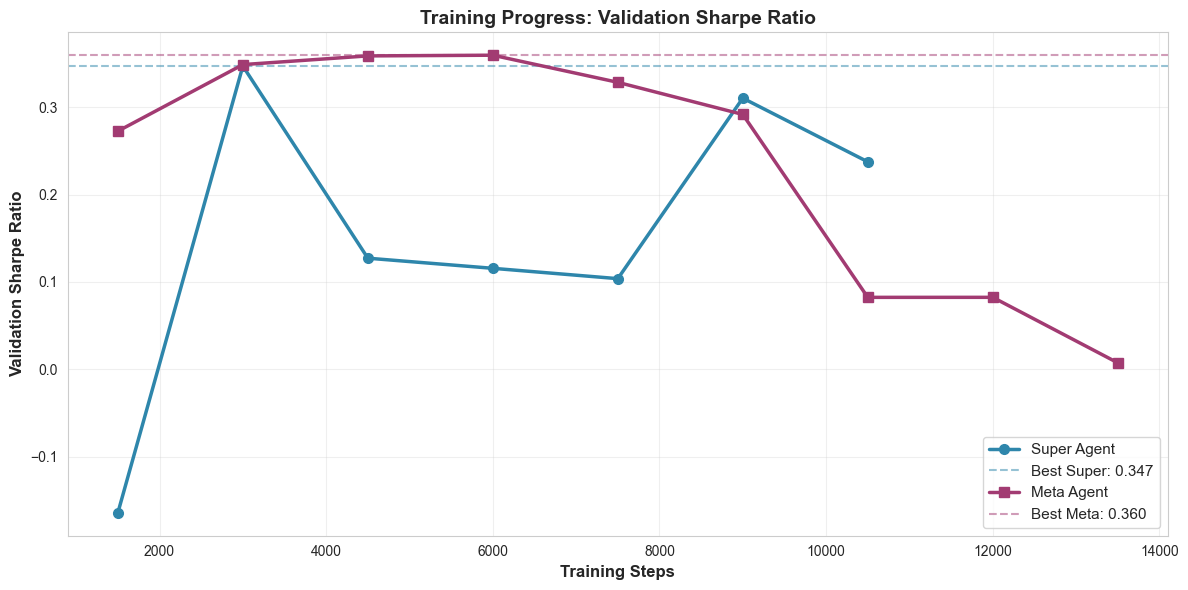

Saved: plots/training_curves.png
2/6 Plotting metrics comparison...


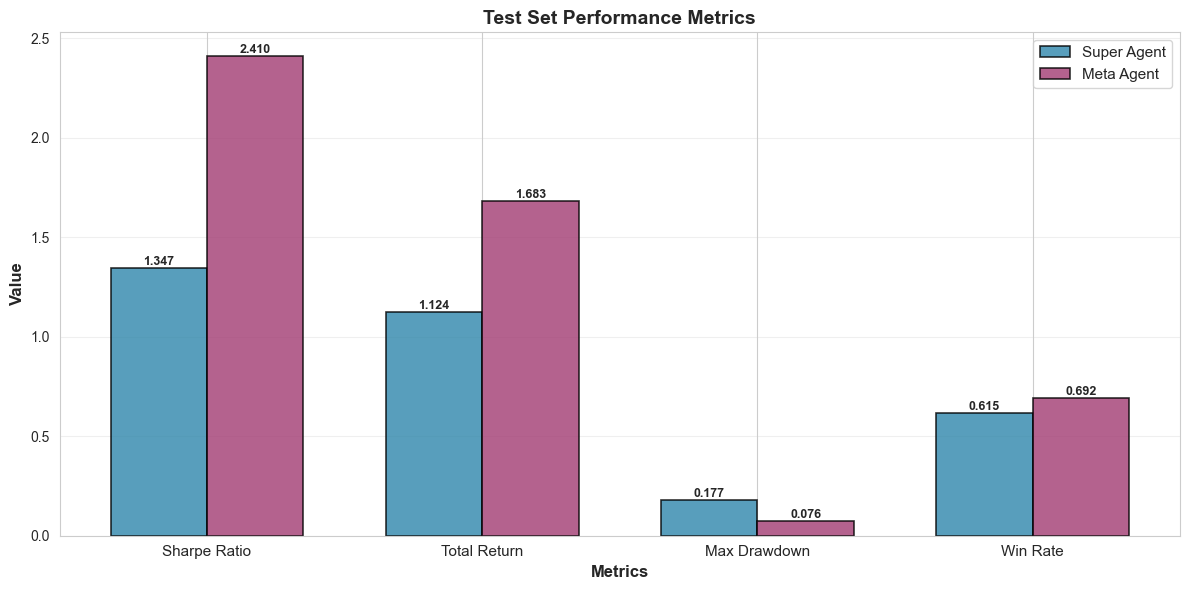

Saved: plots/metrics_comparison.png
3/6 Plotting portfolio evolution...


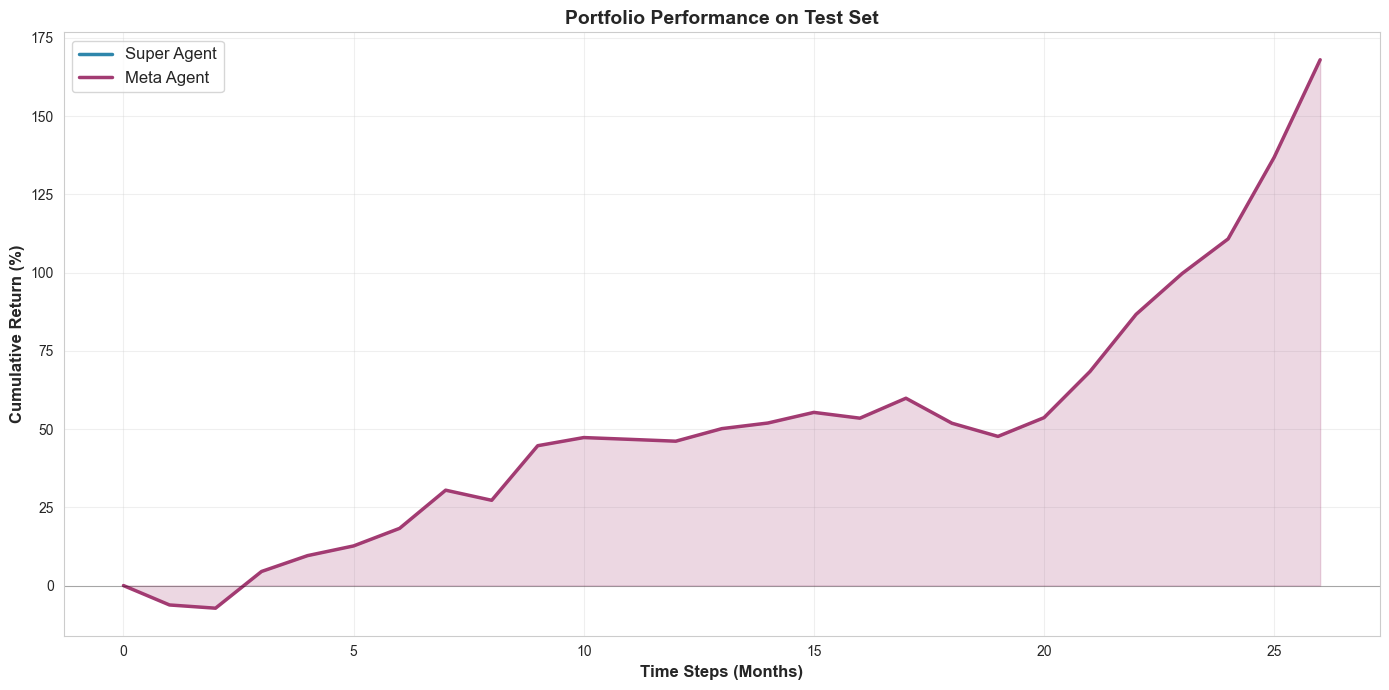

Saved: plots/portfolio_evolution.png
4/6 Plotting drawdown analysis...


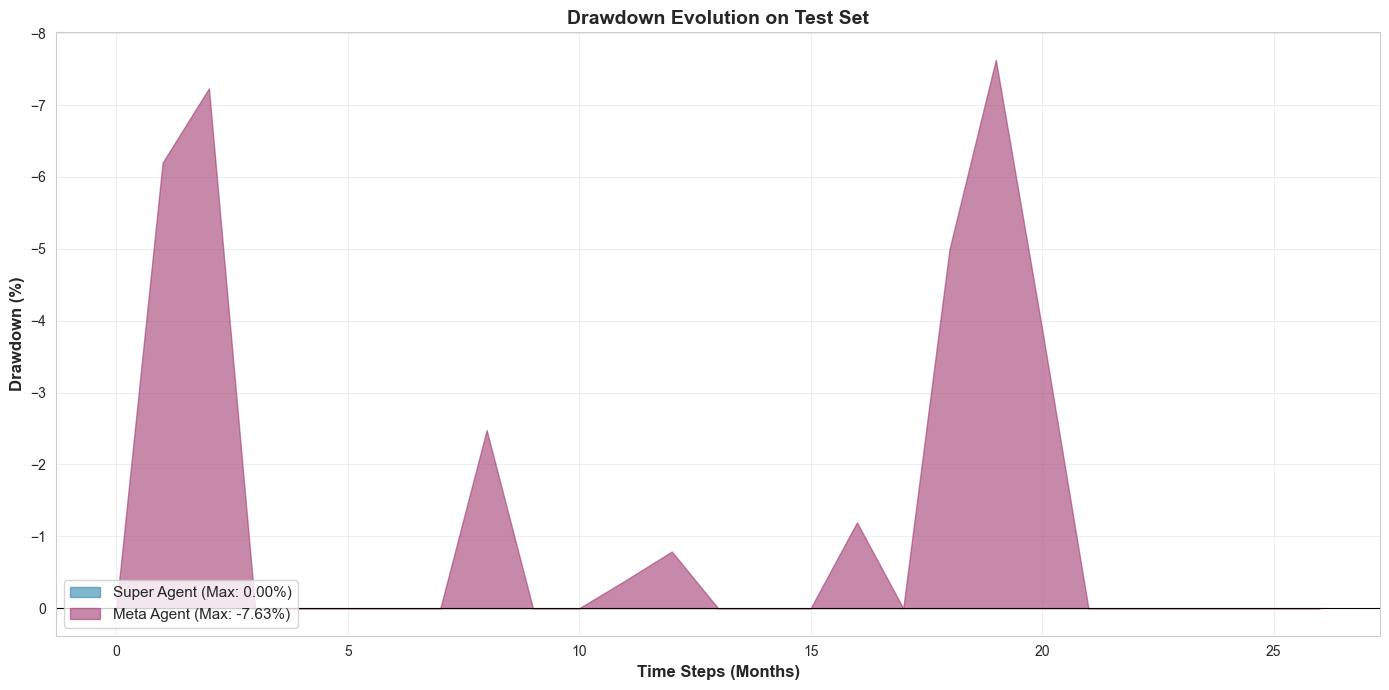

Saved: plots/drawdown_analysis.png
5/6 Plotting agent allocations...


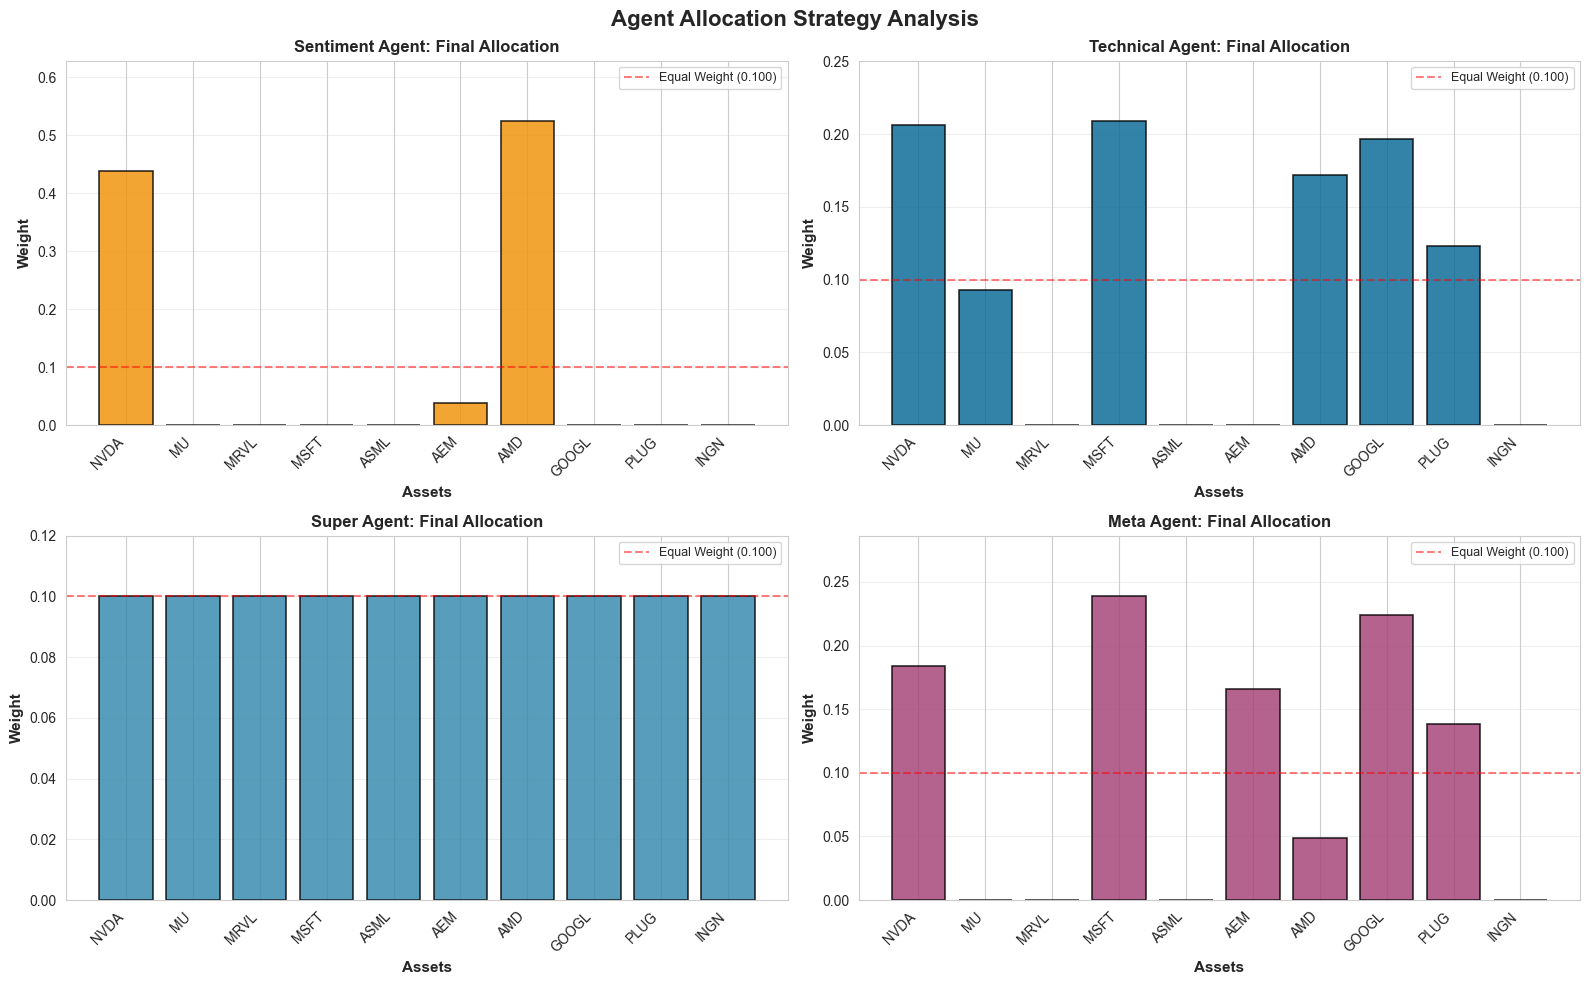

Saved: plots/agent_allocations.png
6/6 Plotting risk-return scatter...


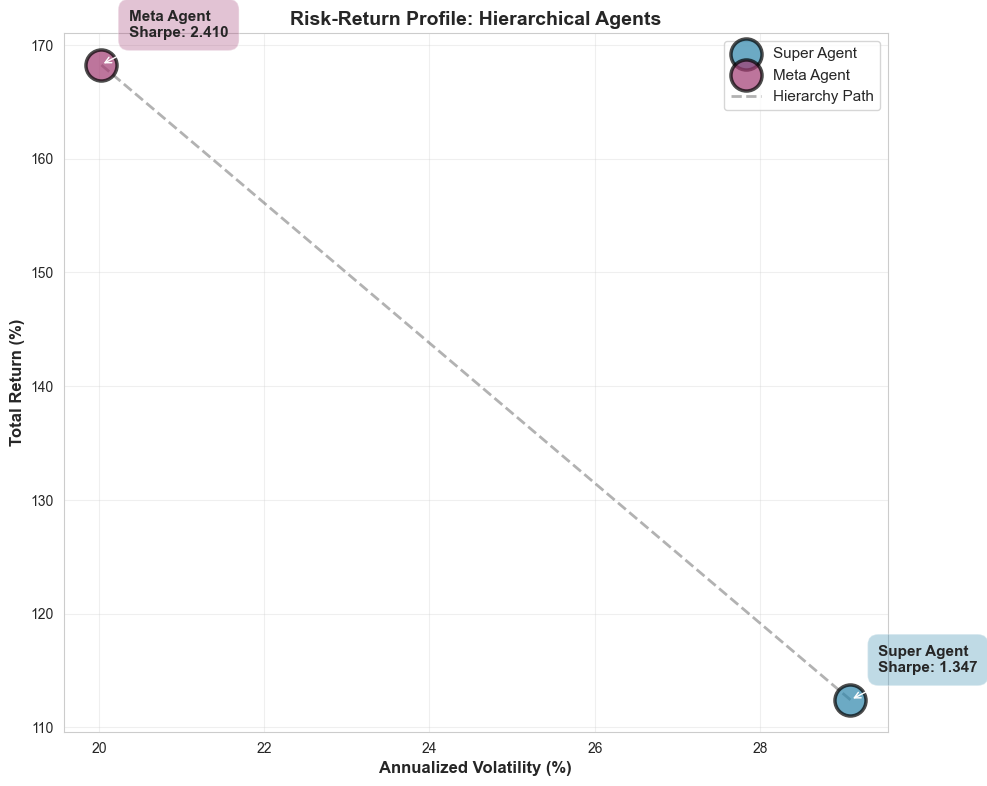

Saved: plots/risk_return_scatter.png

PERFORMANCE COMPARISON TABLE
               Metric Super Agent Meta Agent Improvement
         Sharpe Ratio       1.347      2.410      +78.9%
     Total Return (%)      112.43     168.26      +49.7%
Annualized Return (%)       39.77      55.05      +38.4%
     Max Drawdown (%)       17.73       7.63      +57.0%
       Volatility (%)       29.09      20.03      -31.1%
         Win Rate (%)       61.54      69.23      +12.5%
      Final Value ($)  212,428.38 268,262.12      +26.3%

All visualizations completed!


In [11]:
from viz_utile import *
asset_names = test_prices.columns.tolist()

plot_all_visualizations(
    super_model=super_model,
    meta_model=meta_model,
    super_test_env=super_test_env,
    meta_test_env=meta_test_env,
    super_callback=super_callback,
    meta_callback=meta_callback,
    super_metrics=super_test_metrics,
    meta_metrics=meta_test_metrics,
    sentiment_agent=sentiment_agent,
    technical_agent=technical_agent,
    asset_names=asset_names,
    test_periods=len(test_prices),
    save_dir='plots'
)

In [12]:
from custom_function import print_final_statistics

print_final_statistics(super_test_metrics, meta_test_metrics, len(test_prices))


HIERARCHICAL AGENT TEST SET PERFORMANCE COMPARISON
               Metric Super Agent Meta Agent Improvement
         Sharpe Ratio       1.347      2.410      +78.9%
     Total Return (%)      112.43     168.26      +49.7%
Annualized Return (%)       39.77      55.05      +38.4%
     Max Drawdown (%)       17.73       7.63      +57.0%
       Volatility (%)       29.09      20.03      -31.1%
         Win Rate (%)       61.54      69.23      +12.5%
      Final Value ($)  212,428.38 268,262.12      +26.3%

Note: Positive improvement % is better for all metrics
      (including Max Drawdown, where reduction = improvement)

KEY HIGHLIGHTS
Meta Agent Sharpe Ratio Improvement: +78.9%
Meta Agent Total Return Improvement: +49.7%
Meta Agent Final Portfolio Value: $268,262.12


## Meta Agent Allocation Evolution

Visualize how the meta agent dynamically adjusts portfolio allocations over time in response to changing market conditions.


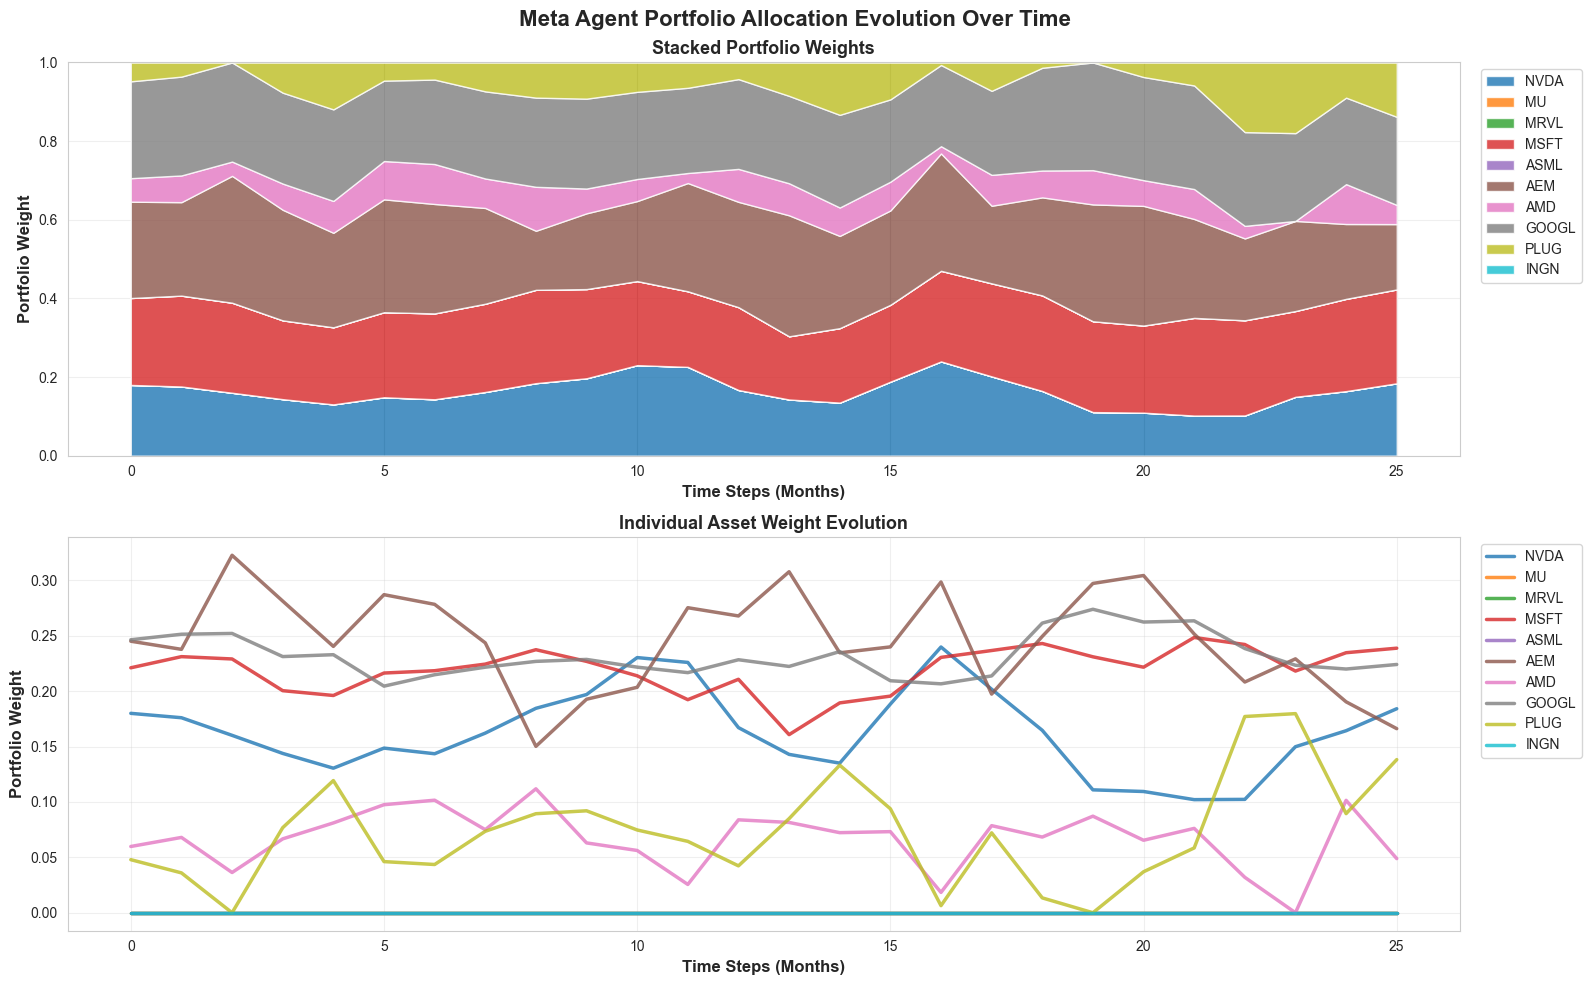

Saved: plots/meta_allocation_evolution.png

Final Portfolio Allocation (Last Month):
NVDA     0.184
MU       0.000
MRVL     0.000
MSFT     0.239
ASML     0.000
AEM      0.166
AMD      0.049
GOOGL    0.224
PLUG     0.138
INGN     0.000
Name: 25, dtype: float32


In [13]:
from viz_utile import plot_meta_allocation_evolution

allocation_df = plot_meta_allocation_evolution(
    meta_model=meta_model,
    meta_test_env=meta_test_env,
    asset_names=asset_names,
    save_path='plots/meta_allocation_evolution.png'
)

print("\nFinal Portfolio Allocation (Last Month):")
print(allocation_df.iloc[-1].round(3))
